In [1]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train.csv


In [2]:
import pandas as pd

df = pd.read_csv("train.csv", encoding='latin-1')
df.head()

,sms,label
0,"Go until jurong point, crazy.. Available only ...",0
1,Ok lar... Joking wif u oni...\n,0
2,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,U dun say so early hor... U c already then say...,0
4,"Nah I don't think he goes to usf, he lives aro...",0


In [3]:
df['label'].value_counts()

,count
label,
0,4827
1,747


In [4]:
import re
import nltk

nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df['clean_message'] = df['sms'].apply(clean_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['clean_message'])

In [6]:
y = df['label']

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

nb = MultinomialNB()
lr = LogisticRegression(max_iter=1000)
svm = SVC()
rf = RandomForestClassifier()

models = {
    "Naive Bayes": nb,
    "Logistic Regression": lr,
    "SVM": svm,
    "Random Forest": rf
}

for name, model in models.items():
    model.fit(X_train, y_train)

In [9]:
from sklearn.metrics import accuracy_score, classification_report

for name, model in models.items():
    y_pred = model.predict(X_test)

    print(f"--- {name} ---")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print()

--- Naive Bayes ---
Accuracy: 0.9713004484304932
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       954
           1       1.00      0.80      0.89       161

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.94      1115
weighted avg       0.97      0.97      0.97      1115


--- Logistic Regression ---
Accuracy: 0.95695067264574
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       954
           1       0.97      0.73      0.83       161

    accuracy                           0.96      1115
   macro avg       0.96      0.86      0.90      1115
weighted avg       0.96      0.96      0.95      1115


--- SVM ---
Accuracy: 0.9748878923766816
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       954
           1       1.00      0.83      0.90       161

    accuracy                       

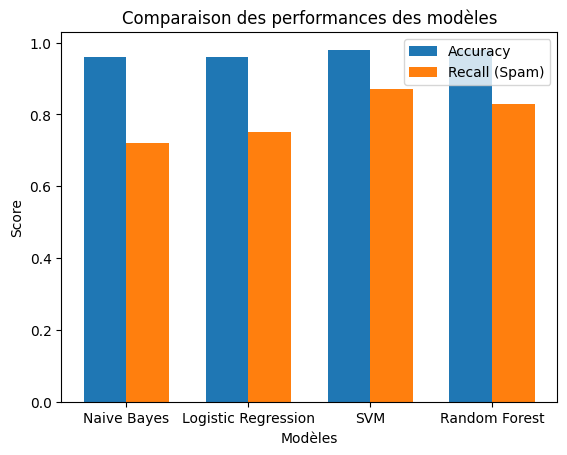

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Données
models = ['Naive Bayes', 'Logistic Regression', 'SVM', 'Random Forest']
accuracy = [0.96, 0.96, 0.98, 0.98]
recall_spam = [0.72, 0.75, 0.87, 0.83]

x = np.arange(len(models))
width = 0.35

plt.figure()

plt.bar(x - width/2, accuracy, width, label='Accuracy')
plt.bar(x + width/2, recall_spam, width, label='Recall (Spam)')

plt.xticks(x, models)
plt.xlabel("Modèles")
plt.ylabel("Score")
plt.title("Comparaison des performances des modèles")

plt.legend()
plt.show()

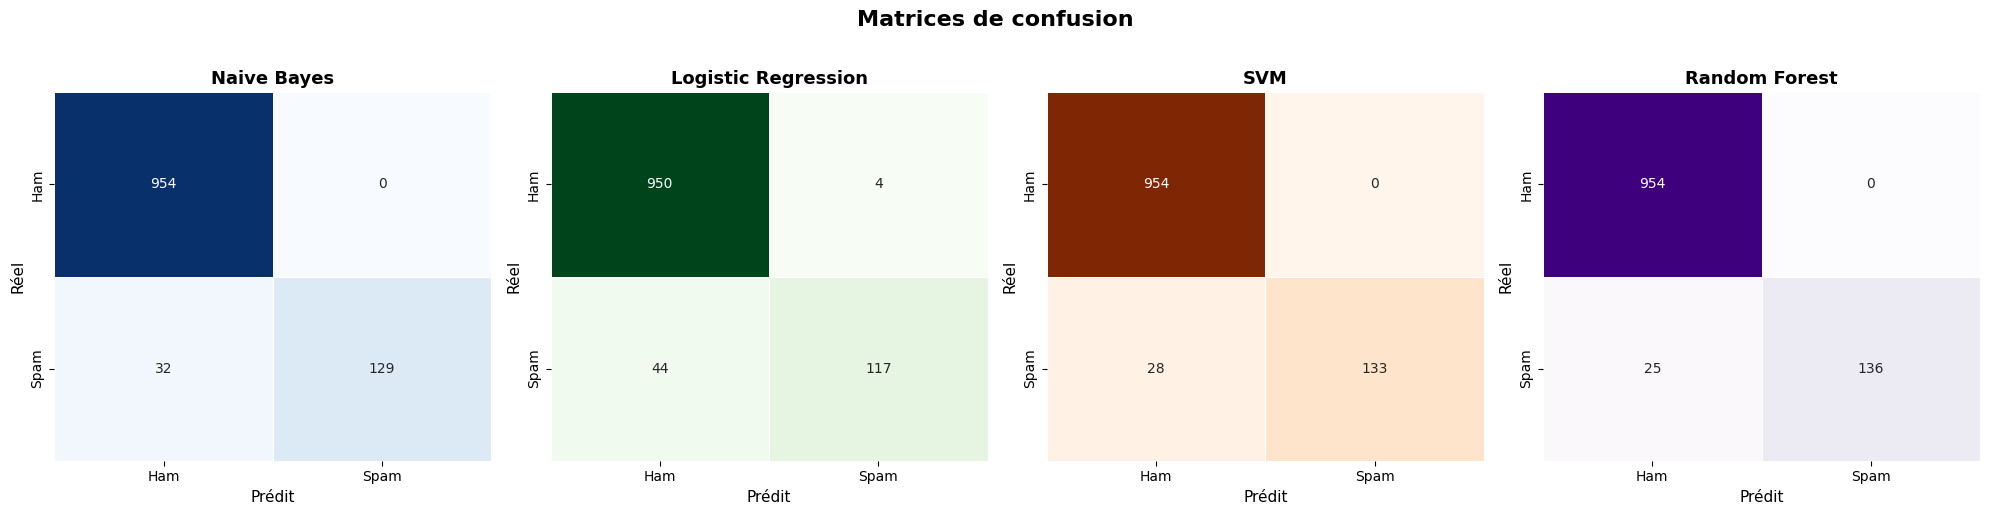

Matrices de confusion affichées avec succès.


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle("Matrices de confusion", fontsize=16, fontweight='bold', y=1.02)

colors = ['Blues', 'Greens', 'Oranges', 'Purples']
models = {
    "Naive Bayes": nb,
    "Logistic Regression": lr,
    "SVM": svm,
    "Random Forest": rf
}
for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)

    # ⚠️ labels numériques corrects
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap=colors[i],
        ax=axes[i],
        xticklabels=['Ham', 'Spam'],
        yticklabels=['Ham', 'Spam'],
        linewidths=0.5,
        cbar=False
    )

    axes[i].set_title(name, fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Prédit', fontsize=11)
    axes[i].set_ylabel('Réel', fontsize=11)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

print("Matrices de confusion affichées avec succès.")

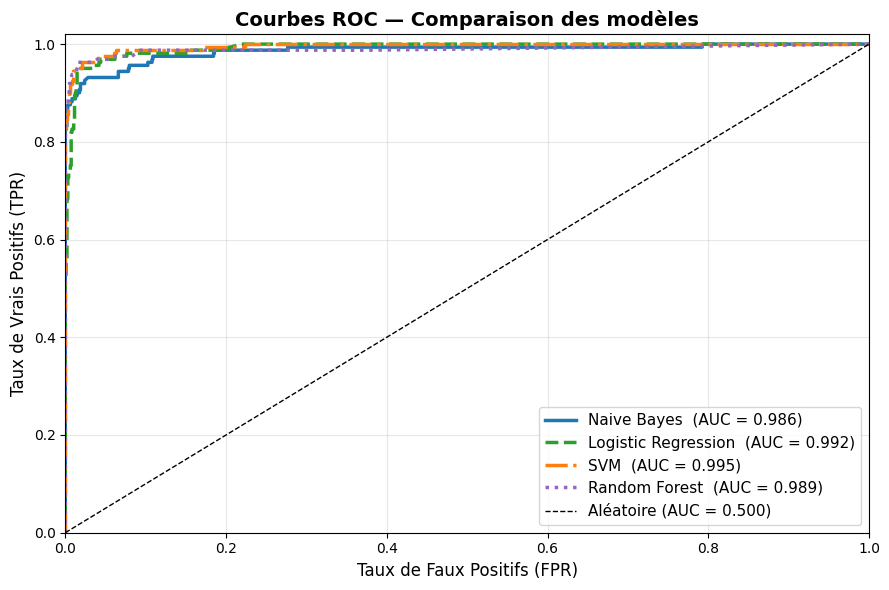

Courbes ROC affichées avec succès.


In [12]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelBinarizer
import matplotlib.pyplot as plt

lb = LabelBinarizer()
lb.fit(y_test)
y_test_bin = lb.transform(y_test).ravel()

fig, ax = plt.subplots(figsize=(9, 6))

colors_roc = ['#1f77b4', '#2ca02c', '#ff7f0e', '#9467bd']
linestyles = ['-', '--', '-.', ':']

for i, (name, model) in enumerate(models.items()):
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test_bin, y_score)
    roc_auc = auc(fpr, tpr)

    ax.plot(
        fpr, tpr,
        color=colors_roc[i],
        linestyle=linestyles[i],
        linewidth=2.5,
        label=f'{name}  (AUC = {roc_auc:.3f})'
    )

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aléatoire (AUC = 0.500)')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.02])
ax.set_xlabel('Taux de Faux Positifs (FPR)', fontsize=12)
ax.set_ylabel('Taux de Vrais Positifs (TPR)', fontsize=12)
ax.set_title('Courbes ROC — Comparaison des modèles', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Courbes ROC affichées avec succès.")